In [1]:
import sys
print(sys.executable)

c:\Users\luisl\OneDrive\Documents\Python Beginner Projects\venv\Scripts\python.exe


# Birkenstock USA Inventory & Sales Analytics

**Author:** Luis  
**Date:** April 2026  
**Level:** Beginner  
**Tools:** Python, SQL (SQLite), Pandas, Matplotlib, Seaborn  

## Business Questions:
1. Which styles generate the most revenue?
2. Which categories (Men/Women/Kids) drive most sales?
3. Which styles have the highest dead stock?
4. Which sizes are most frequently understocked?
5. Which incoming shipments arrived in the wrong season?

In [2]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import random
from datetime import datetime, timedelta

print("Imports successful")

Imports successful


In [3]:
# Cell 3: Generate synthetic Birkenstock USA inventory and sales data

random.seed(42)
np.random.seed(42)

# ── PRODUCTS ──────────────────────────────────────────────────────────────────

products = [
    # (product_id, style, material, gender, width, price, category, season, is_discontinued)
    (1,  'Arizona',  'Birko-Flor',  'Womens',  'R', 109.95, 'Sandal', 'Spring/Summer', 0),
    (2,  'Arizona',  'Birko-Flor',  'Womens',  'N', 109.95, 'Sandal', 'Spring/Summer', 0),
    (3,  'Arizona',  'Suede',       'Womens',  'R', 139.95, 'Sandal', 'Spring/Summer', 0),
    (4,  'Arizona',  'Suede',       'Mens',    'R', 139.95, 'Sandal', 'Spring/Summer', 0),
    (5,  'Arizona',  'EVA',         'Unisex',  'R',  49.95, 'Sandal', 'Spring/Summer', 0),
    (6,  'Boston',   'Suede',       'Womens',  'R', 154.95, 'Clog',   'Fall/Winter',   0),
    (7,  'Boston',   'Suede',       'Mens',    'R', 154.95, 'Clog',   'Fall/Winter',   0),
    (8,  'Boston',   'Suede',       'Womens',  'N', 154.95, 'Clog',   'Fall/Winter',   0),
    (9,  'Boston',   'Oiled Leather','Mens',   'R', 164.95, 'Clog',   'Fall/Winter',   0),
    (10, 'Gizeh',    'Birko-Flor',  'Womens',  'R', 109.95, 'Sandal', 'Spring/Summer', 0),
    (11, 'Gizeh',    'Suede',       'Womens',  'R', 139.95, 'Sandal', 'Spring/Summer', 0),
    (12, 'Gizeh',    'EVA',         'Unisex',  'R',  49.95, 'Sandal', 'Spring/Summer', 0),
    (13, 'Florida',  'Birko-Flor',  'Womens',  'R', 119.95, 'Sandal', 'Spring/Summer', 0),
    (14, 'Florida',  'Birko-Flor',  'Womens',  'N', 119.95, 'Sandal', 'Spring/Summer', 0),
    (15, 'Highwood', 'Suede',       'Mens',    'R', 159.95, 'Boot',   'Fall/Winter',   0),
    (16, 'Highwood', 'Suede',       'Womens',  'R', 159.95, 'Boot',   'Fall/Winter',   0),
    (17, 'Bend Low', 'Leather',     'Mens',    'R', 164.95, 'Sneaker','Fall/Winter',   0),
    (18, 'Bend Low', 'Leather',     'Womens',  'R', 164.95, 'Sneaker','Fall/Winter',   0),
    (19, 'Naples',   'Birko-Flor',  'Womens',  'R', 114.95, 'Sandal', 'Spring/Summer', 1),
    (20, 'Naples',   'Birko-Flor',  'Mens',    'R', 114.95, 'Sandal', 'Spring/Summer', 1),
    (21, 'Arizona',  'Birko-Flor',  'Kids',    'R',  64.95, 'Sandal', 'Spring/Summer', 0),
    (22, 'Boston',   'Birko-Flor',  'Kids',    'R',  69.95, 'Clog',   'Fall/Winter',   0),
    (23, 'Footbed',  'Cork/Latex',  'Unisex',  'R',  44.95, 'Accessory', 'All Season', 0),
    (24, 'Socks',    'Wool',        'Unisex',  'R',  16.95, 'Accessory', 'All Season', 0),
]

products_df = pd.DataFrame(products, columns=[
    'product_id', 'style', 'material', 'gender', 'width', 'price', 
    'category', 'season', 'is_discontinued'
])

# ── SIZES ─────────────────────────────────────────────────────────────────────

def get_sizes(gender):
    if gender == 'Womens':
        return [35, 36, 37, 38, 39, 40, 41, 42]
    elif gender == 'Mens':
        return [40, 41, 42, 43, 44, 45, 46]
    elif gender == 'Kids':
        return [28, 29, 30, 31, 32]
    else:
        return [36, 37, 38, 39, 40, 41, 42, 43]

# ── INVENTORY ─────────────────────────────────────────────────────────────────

rare_sizes = [35, 46, 47, 48]

inventory_records = []
inventory_id = 1

for _, product in products_df.iterrows():
    if product['category'] == 'Accessory':
        inventory_records.append((
            inventory_id, product['product_id'], None, None,
            random.randint(20, 80), 10, random.randint(1, 90)
        ))
        inventory_id += 1
        continue

    sizes = get_sizes(product['gender'])
    for size in sizes:
        is_rare = size in rare_sizes
        if is_rare:
            quantity = random.randint(0, 4)
        elif product['is_discontinued']:
            quantity = random.randint(5, 25)
        elif product['season'] == 'Fall/Winter':
            quantity = random.randint(2, 15)
        else:
            quantity = random.randint(5, 40)

        reorder_point = 3 if is_rare else 8
        days_in_stock = random.randint(60, 180) if product['is_discontinued'] else random.randint(1, 60)

        inventory_records.append((
            inventory_id, product['product_id'], size,
            product['width'], quantity, reorder_point, days_in_stock
        ))
        inventory_id += 1

inventory_df = pd.DataFrame(inventory_records, columns=[
    'inventory_id', 'product_id', 'size_eu', 'width',
    'quantity_on_hand', 'reorder_point', 'days_in_stock'
])

# ── SALES ───────

sales_records = []
sale_id = 1
start_date = datetime(2026, 1, 1)
end_date = datetime(2026, 4, 20)

for _, product in products_df.iterrows():
    if product['category'] == 'Accessory':
        num_sales = random.randint(5, 20)
        for _ in range(num_sales):
            sale_date = start_date + timedelta(days=random.randint(0, (end_date - start_date).days))
            sales_records.append((
                sale_id, product['product_id'], None,
                product['width'], 1, sale_date.strftime('%Y-%m-%d'), product['price']
            ))
            sale_id += 1
        continue

    sizes = get_sizes(product['gender'])
    for size in sizes:
        is_rare = size in rare_sizes
        if is_rare:
            num_sales = random.randint(0, 3)
        elif product['is_discontinued']:
            num_sales = random.randint(1, 5)
        elif product['season'] == 'Spring/Summer':
            num_sales = random.randint(8, 30)
        else:
            num_sales = random.randint(2, 10)

        for _ in range(num_sales):
            sale_date = start_date + timedelta(days=random.randint(0, (end_date - start_date).days))
            sales_records.append((
                sale_id, product['product_id'], size,
                product['width'], 1, sale_date.strftime('%Y-%m-%d'), product['price']
            ))
            sale_id += 1

sales_df = pd.DataFrame(sales_records, columns=[
    'sale_id', 'product_id', 'size_eu', 'width',
    'quantity_sold', 'sale_date', 'sale_price'
])

# ── INCOMING SHIPMENTS ────────────────────────────────────────────────────────

shipments = [
    (1,  6,  48, '2026-04-01', '2026-04-05', 'Fall/Winter',  'Late - wrong season'),
    (2,  7,  36, '2026-04-10', '2026-04-12', 'Fall/Winter',  'Late - wrong season'),
    (3,  15, 24, '2026-03-15', '2026-03-18', 'Fall/Winter',  'Late - wrong season'),
    (4,  16, 30, '2026-04-08', '2026-04-09', 'Fall/Winter',  'Late - wrong season'),
    (5,  1,  60, '2026-03-01', '2026-03-03', 'Spring/Summer','On time'),
    (6,  3,  48, '2026-02-15', '2026-02-18', 'Spring/Summer','On time'),
    (7,  10, 54, '2026-03-10', '2026-03-12', 'Spring/Summer','On time'),
    (8,  17, 20, '2026-04-15', '2026-04-18', 'Fall/Winter',  'Late - wrong season'),
    (9,  5,  72, '2026-03-05', '2026-03-06', 'Spring/Summer','On time'),
    (10, 23, 40, '2026-02-20', '2026-02-22', 'All Season',   'On time'),
]

shipments_df = pd.DataFrame(shipments, columns=[
    'shipment_id', 'product_id', 'quantity',
    'expected_date', 'actual_date', 'season_intended', 'status'
])

print("Synthetic dataset created successfully")
print(f"Products:   {len(products_df)} records")
print(f"Inventory:  {len(inventory_df)} records")
print(f"Sales:      {len(sales_df)} records")
print(f"Shipments:  {len(shipments_df)} records")

Synthetic dataset created successfully
Products:   24 records
Inventory:  166 records
Sales:      1828 records
Shipments:  10 records


In [4]:
import sqlite3

conn = sqlite3.connect('../data/birkenstock.db')

In [5]:
products_df.to_sql('products', conn, if_exists='replace', index=False)
inventory_df.to_sql('inventory', conn, if_exists='replace', index=False)
sales_df.to_sql('sales', conn,  if_exists='replace', index=False  )
shipments_df.to_sql('shipments', conn, if_exists='replace', index=False)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print('Tables in database:', cursor.fetchall())

Tables in database: [('products',), ('inventory',), ('sales',), ('shipments',)]


In [6]:
query = """
SELECT
    p.style, 
    COUNT(s.sale_id) AS total_units_sold,
    SUM(s.sale_price) AS total_revenue
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY p.style
ORDER BY total_revenue DESC
"""

result = pd.read_sql_query(query, conn)
print(result)

      style  total_units_sold  total_revenue
0   Arizona               742       75387.90
1     Gizeh               402       39129.90
2   Florida               274       32866.30
3    Boston               159       23082.05
4  Bend Low                94       15505.30
5  Highwood                85       13595.75
6    Naples                49        5632.55
7   Footbed                18         809.10
8     Socks                 5          84.75


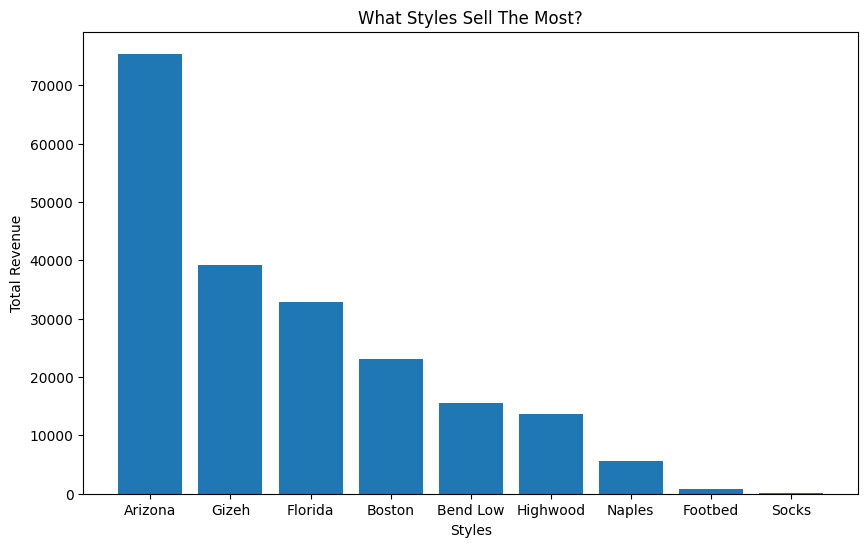

In [7]:
plt.figure(figsize=(10,6)) 
plt.bar(result['style'], result['total_revenue']  )
plt.xlabel('Styles')
plt.ylabel('Total Revenue')
plt.title('What Styles Sell The Most?')
plt.show()


In [8]:
query = """
SELECT 
    p.gender,
    COUNT(s.sale_id) AS total_units_sold,
    SUM(s.sale_price) AS total_revenue
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY gender
ORDER BY total_revenue DESC
 """

result = pd.read_sql_query(query, conn)
print(result)

   gender  total_units_sold  total_revenue
0  Womens              1094       139430.3
1    Mens               288        43145.6
2  Unisex               354        17427.3
3    Kids                92         6090.4


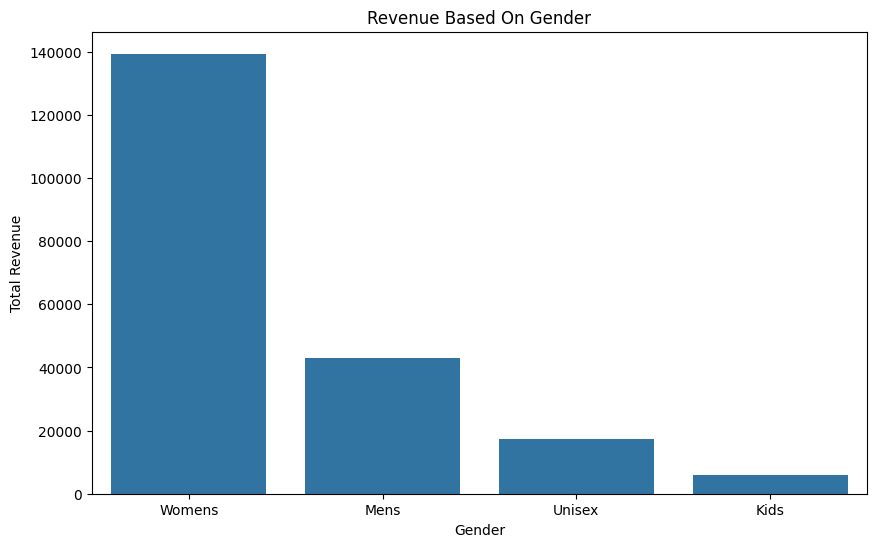

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(data=result, x=result['gender'], y=result['total_revenue'])
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.title('Revenue Based On Gender')
plt.show()

In [46]:
#Style name (from products)
#Average days in stock (from inventory)
#Total quantity on hand (from inventory)
#JOIN inventory → products
#GROUP BY style
#ORDER BY average days in stock (highest first)
query = """
SELECT 
    p.style,
    AVG(i.days_in_stock) AS avg_days_in_stock,
    SUM(i.quantity_on_hand) AS total_quantity
FROM inventory i
JOIN products p ON i.product_id = p.product_id
WHERE p.category != 'Accessory'
GROUP BY p.style
ORDER BY avg_days_in_stock DESC
"""
result=pd.read_sql_query(query, conn)
print(result)

      style  avg_days_in_stock  total_quantity
0    Naples         114.266667             188
1     Gizeh          35.250000             451
2   Florida          32.937500             279
3    Boston          32.257143             281
4   Arizona          28.477273             852
5  Highwood          27.266667             119
6  Bend Low          25.400000             110


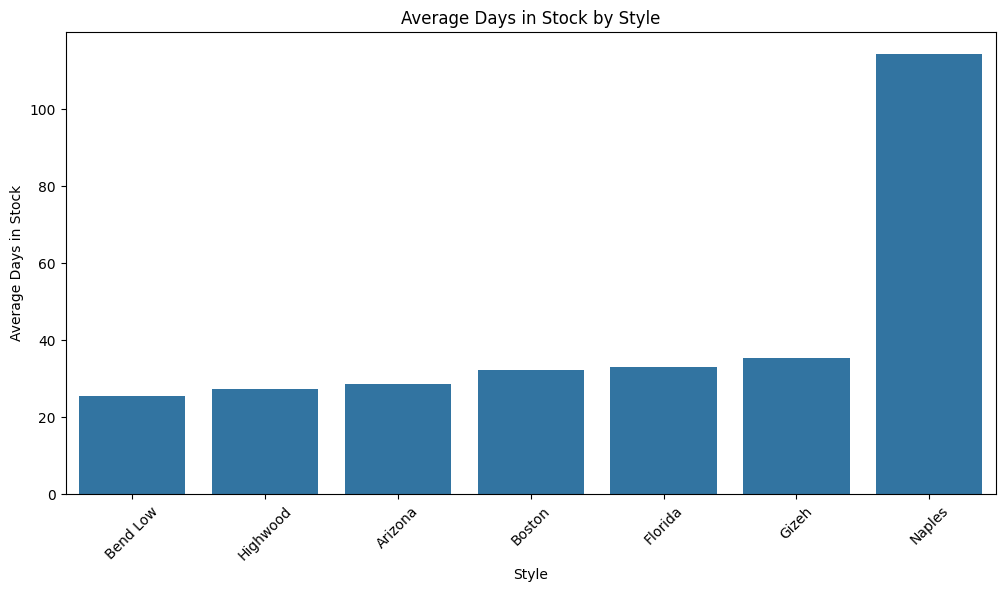

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(data=result, x=result['style'], y=result['avg_days_in_stock'])
plt.xticks(rotation=45)
plt.title('Average Days in Stock by Style')
plt.xlabel('Style')
plt.ylabel('Average Days in Stock')
result.sort_values('avg_days_in_stock', ascending=True, inplace=False)
plt.show()

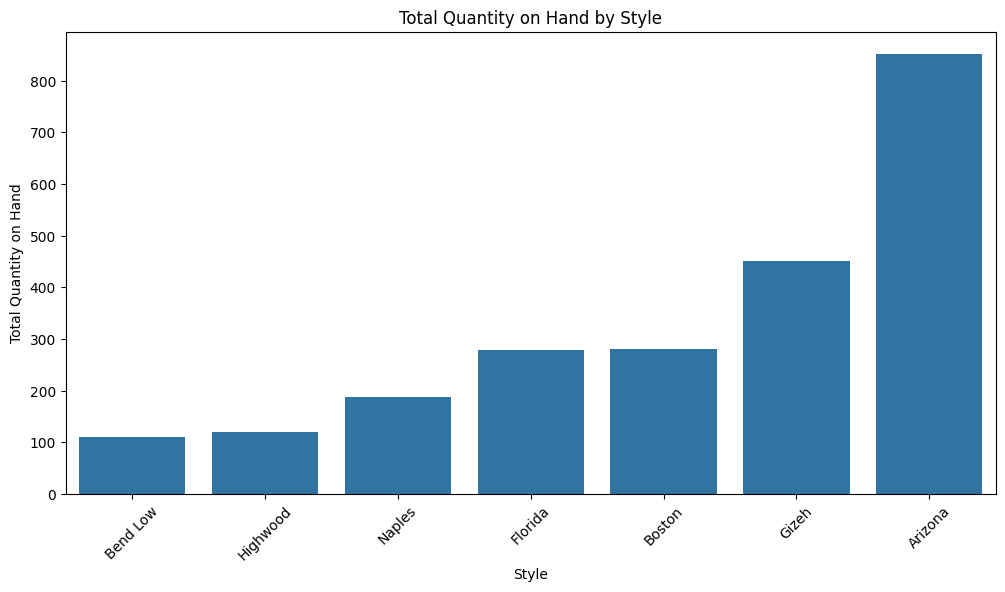

In [25]:
sorted_result = result.sort_values('total_quantity', ascending=True)
plt.figure(figsize=(12,6))
sns.barplot(data=sorted_result, x=sorted_result['style'], y=sorted_result['total_quantity'])  
plt.xticks(rotation=45)
plt.title('Total Quantity on Hand by Style')
plt.xlabel('Style')
plt.ylabel('Total Quantity on Hand')
plt.show()

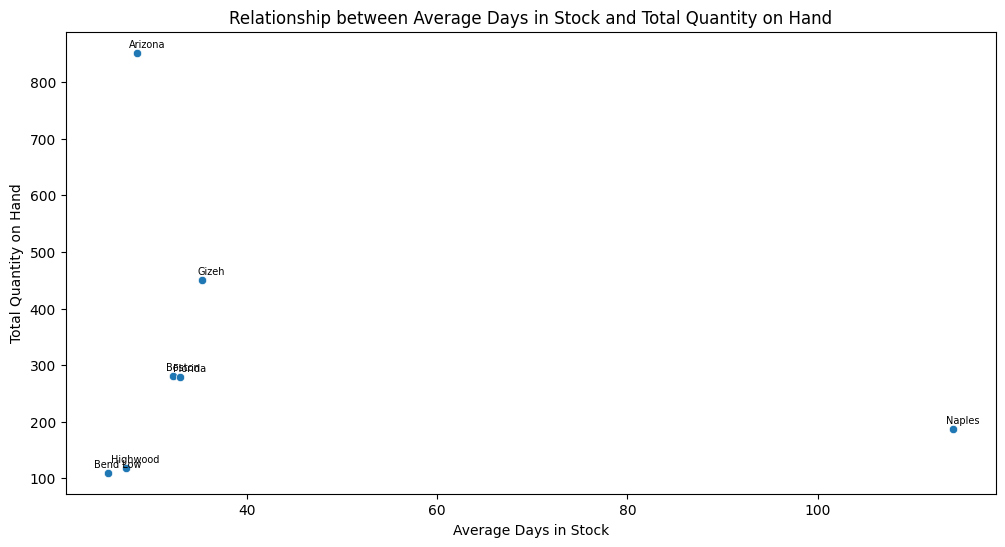

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=result, x=result['avg_days_in_stock'], y=result['total_quantity'])
plt.xlabel('Average Days in Stock')
plt.ylabel('Total Quantity on Hand')

#Loop through each point and add a label
for i, row in result.iterrows():
    plt.text(row['avg_days_in_stock'] + 1, row['total_quantity'] + 10, row['style'], fontsize=7, ha='center')
plt.title('Relationship between Average Days in Stock and Total Quantity on Hand')
plt.show()  #Boston and Florida are overlapping, therefore the labels are hard to read. In a real analysis, I would consider using a different visualization or adjusting the labels to avoid overlap.

In [ ]:
#Simple code to find styles where the average quantity on hand is less than 200 and average days in stock is less than 40, because those are selling fast but we don't have enough of them

fast_selling_low_stock = result[(result['total_quantity'] < 200) & (result['avg_days_in_stock'] < 40)]    
print(fast_selling_low_stock)

      style  avg_days_in_stock  total_quantity
6  Bend Low          25.400000             110
5  Highwood          27.266667             119


In [47]:
# SQL query to find styles where the average quantity on hand is less than 200 and average days in stock is less than 40, because those are selling fast but we don't have enough of them
query = """
SELECT  p.style,
        AVG(i.days_in_stock) AS avg_days_in_stock, 
        AVG(i.quantity_on_hand) AS avg_quantity_on_hand
FROM    products p
JOIN inventory i ON p.product_id = i.product_id
WHERE p.category != 'Accessory'
GROUP BY p.style
HAVING  AVG(i.quantity_on_hand) < 200 AND AVG(i.days_in_stock) < 40
"""
result = pd.read_sql_query(query, conn)
print(result)

      style  avg_days_in_stock  avg_quantity_on_hand
0   Arizona          28.477273             19.363636
1  Bend Low          25.400000              7.333333
2    Boston          32.257143              8.028571
3   Florida          32.937500             17.437500
4     Gizeh          35.250000             18.791667
5  Highwood          27.266667              7.933333


In [51]:
#Make a query that counts how many shipments are on time vs late, and how many of the late shipments are late because they were the wrong season, then calculate the percentage of each out of total shipments
query = """
SELECT 
    COUNT(*) AS total_shipments,
    COUNT(CASE WHEN status = 'On time' THEN 1 END) AS on_time_count,
    COUNT(CASE WHEN status = 'Late - wrong season' THEN 1 END) AS late_count,
    ROUND(COUNT(CASE WHEN status = 'On time' THEN 1 END) * 100.0 / COUNT(*), 2) AS on_time_percentage,
    ROUND(COUNT(CASE WHEN status = 'Late - wrong season' THEN 1 END) * 100.0 / COUNT(*), 2) AS late_percentage
FROM shipments s


"""
result = pd.read_sql_query(query, conn)
print(result)

   total_shipments  on_time_count  late_count  on_time_percentage  \
0               10              5           5                50.0   

   late_percentage  
0             50.0  


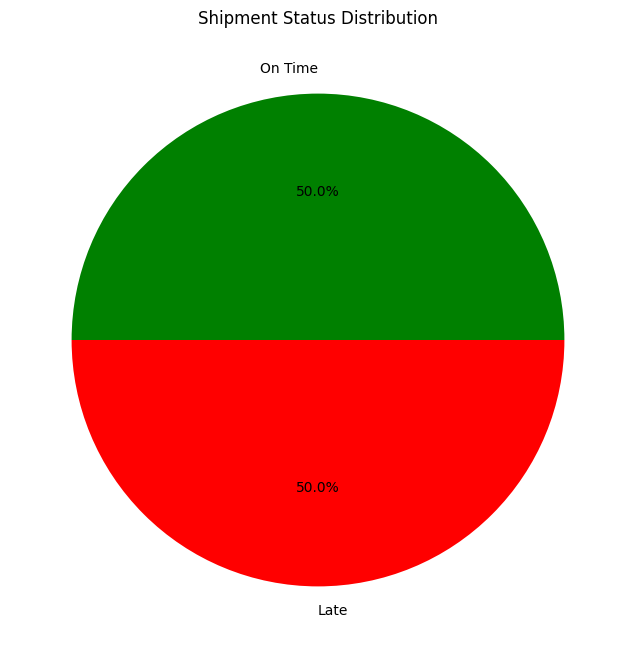

In [53]:
#Make a pie chart to compare the number of late shipments vs on time shipments
plt.figure(figsize=(8, 8))
plt.pie([result['on_time_count'].iloc[0], result['late_count'].iloc[0]], labels=['On Time', 'Late'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Shipment Status Distribution')
plt.show()

Project Overview 

I felt the need to do an sql project as an apsiring data analyst, and I thought there was no better topic cover than a store's inventory. In this case I chose my own workplace at Birkenstock because I am a Stock Lead and have a good idea of what goes on behind the scenes in a retail environment. Now for the project, I decided to create an inventory checker with a fabricated dataframe to check what's in stock, what's out of stock, shipment times, high performing product vs low performing product, and how to make decisions based on these insights.

Data 

The data used was synthetic for simplicity, I may do a separate project with real data in the near future. As for the tables; Products, Inventory, Sales, and Shipments.
The Products table included all Birkenstock styles, materials, gender, price, category, season, and discontinued status.  The inventory table contained stock levels per style and size, quantity on hand, reorder points, days in stock. The Sales table had transaction records from January to April 2026, sale dates, prices, sizes sold. Lastly, the shipments table had info on incoming stock records including expected vs actual arrival dates and season status.

Business Questions and Findings

1. Which styles generate the most revenue?
Finding: Arizona led all styles with 742 units sold and $75,387 in revenue. Gizeh followed with 402 units and $39,129. Naples generated the least revenue among footwear with only 49 units and $5,632.
Business Insight: Arizona and Gizeh dominate revenue during spring/summer months due to their open-toe sandal design appealing to warmer weather shoppers. Priority should be given to keeping these styles fully stocked during peak season.

2. Which gender category drives the most sales?
Finding: Womens generated $139,430 in revenue accounting for the overwhelming majority of sales. Mens followed at $43,145 and Kids at $6,090.
Business Insight: Womens sizing should be prioritized in all ordering decisions. During warmer months women purchase open-toe sandals at a significantly higher rate than men, which is consistent with real retail patterns.

3. Which styles have the highest dead stock?
Finding: Naples averaged 114 days in stock with 188 units on hand, far exceeding every other style. All other styles averaged between 25-35 days.
Business Insight: Naples is a discontinued style and should be returned to the warehouse or marked down to clear floor and stockroom space. Every day Naples sits is lost revenue opportunity for faster moving styles.

4. Which sizes are most frequently understocked?
Finding: Six styles were flagged as understocked with average quantity under 200 and average days in stock under 40. Bend Low and Highwood averaged only 7-8 units per size. Boston averaged 8 units per size.
Business Insight: Boston is approaching its peak Fall/Winter season and needs immediate replenishment. Arizona and Gizeh need broader size variety rather than higher quantities in core sizes. Rare sizes (35N, 46R) are consistently underrepresented across all styles.

5. Which shipments arrived in the wrong season?
Finding: 5 out of 10 shipments (50%) arrived late and out of season. All 5 wrong season shipments were Fall/Winter styles (Boston, Highwood, Bend Low) arriving in April during Spring/Summer season.
Business Insight: A 50% wrong season shipment rate is a serious supply chain issue. Fall/Winter stock arriving in April fills stockroom space needed for Spring/Summer inventory and cannot be sold immediately, tying up capital in unsellable product.

What I Learned

This was my first run with SQL, and I learned a lot even while doing a project as simple as this. To begin, I worked on how to grab data from tables and then visualize that data. Learning SELECT, CASE, WHERE, and other SQL clauses was a good amount of fun because SQL reads almost like plain English. After grabbing the data from the tables I created, I then used Python to visualize what I had from the queries. I created bar charts, scatter plots, and a pie chart to tell the story behind each business question.

What made this project unique was that I was able to apply real world retail knowledge from my experience as a stock lead at Birkenstock. The data I generated was modeled after actual inventory patterns I see on the floor every day, which made the analysis feel genuine rather than just an exercise. Identifying dead stock, understocked styles, and wrong season shipments are problems I deal with in real life, so being able to quantify and visualize them was a valuable experience.

Going forward I plan to connect this dataset to Power BI and Excel to build on the analysis further. SQL is a skill I intend to keep developing through dedicated interview preparation, and this project gave me a strong foundation to build from.

Potential Improvements

1. Real Data - This project used synthetic data modeled after real retail patterns. 
Connecting to an actual Birkenstock POS system or sales database would produce 
more accurate and actionable insights.

2. Larger Dataset - Our dataset covered January to April 2026 at a single location. 
Expanding to multiple store locations and full year data would reveal seasonal trends 
and regional differences in buying patterns.

3. Size Level Analysis - Our understocked analysis looked at style level averages. 
A deeper analysis at the individual size level (35N, 46R etc.) would pinpoint 
exactly which sizes need attention rather than flagging entire styles.

4. Reorder Automation - Instead of manually identifying understocked styles, 
a script could automatically generate purchase orders when quantity on hand 
drops below the reorder point threshold.

5. Shipment Tracking - Expanding the shipments table to include supplier information, 
shipping costs, and delay reasons would allow for supplier performance analysis 
and cost optimization.

6. Power BI Integration - Connecting this SQLite database directly to Power BI 
would allow for an interactive dashboard where managers could filter by style, 
gender, season, and size in real time rather than running individual queries.